# Conversión de formatos: CSV, Parquet, JSON y SQL

En esta clase practicaremos cómo cargar un conjunto de datos y guardarlo en distintos formatos. Para cada formato se mostrará la operación de escritura y cómo volver a leer los datos.

El objetivo de este notebook es aprender las operaciones de conversión. Las ventajas y desventajas de cada formato dentro de un pipeline MLOps se analizarán por separado en el siguiente material.

Usaremos el conjunto de recomendación de cultivos. Los archivos generados se guardarán en `data/processed/`.

## 1. Preparar los datos de origen

Primero identificamos el archivo original, lo cargamos en un `DataFrame` de pandas y definimos la carpeta donde guardaremos las conversiones.

In [10]:
# Preparar el conjunto de datos de origen
from pathlib import Path
import pandas as pd

# Resolver la raíz del proyecto desde la raíz o desde la carpeta notebooks.
project_root = Path.cwd()
source_path = project_root / "data" / "raw" / "Crop_recommendation.csv"
if not source_path.exists():
    project_root = project_root.parent
    source_path = project_root / "data" / "raw" / "Crop_recommendation.csv"

output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

if not source_path.exists():
    raise FileNotFoundError(f"No se encontró el CSV de origen: {source_path}")

df = pd.read_csv(source_path)
print(f"CSV de origen: {source_path}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

CSV de origen: c:\Users\marco\ml-demo1-profesor\data\raw\Crop_recommendation.csv
Dimensiones: 2,200 filas × 8 columnas


## 2. Guardar y leer como CSV

**Qué es:** CSV (*Comma-Separated Values*) es un archivo de texto que representa una tabla. La primera fila suele contener los nombres de las columnas y las siguientes, los registros; los valores se separan por comas u otro delimitador.

**Cómo se maneja:** pandas lo carga con `pd.read_csv(ruta)` y lo guarda con `df.to_csv(ruta, index=False)`. Usamos `index=False` para no agregar al archivo el índice interno del DataFrame como una columna adicional. Es un formato legible con un editor de texto o una hoja de cálculo.

In [9]:
csv_path = output_dir / "crop.csv"
df.to_csv(csv_path, index=False)
df_csv = pd.read_csv(csv_path)

print(f"CSV guardado en: {csv_path}")
print(f"Dimensiones al volver a leer: {df_csv.shape}")
df_csv.head()

CSV guardado en: c:\Users\marco\ml-demo1-profesor\data\processed\crop.csv
Dimensiones al volver a leer: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Guardar y leer como Parquet

**Qué es:** Parquet es un formato binario columnar. Organiza los valores por columna y almacena metadatos sobre los tipos de datos; no está pensado para editarse directamente en un editor de texto.

**Cómo se maneja:** pandas lo guarda con `df.to_parquet(ruta, index=False)` y lo carga con `pd.read_parquet(ruta)`. Estas operaciones requieren un motor compatible, como PyArrow. En este notebook nos enfocamos en las operaciones de lectura y escritura; sus ventajas y desventajas para MLOps se compararán en el siguiente material.

In [4]:
parquet_path = output_dir / "crop.parquet"
df.to_parquet(parquet_path, index=False)
df_parquet = pd.read_parquet(parquet_path)

print(f"Parquet guardado en: {parquet_path}")
print(f"Dimensiones al volver a leer: {df_parquet.shape}")
df_parquet.head()

Parquet guardado en: c:\Users\marco\ml-demo1-profesor\data\processed\crop.parquet
Dimensiones al volver a leer: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 4. Guardar y leer como JSON

**Qué es:** JSON es un formato de texto estructurado que representa objetos como pares `clave: valor` y colecciones como listas. Se usa con frecuencia para intercambiar datos entre aplicaciones y servicios.

**Cómo se maneja:** con `orient="records"`, cada fila del DataFrame se convierte en un objeto y el archivo contiene una lista de objetos. Se escribe con `df.to_json(ruta, orient="records")` y se lee con `pd.read_json(ruta, orient="records")`. Conviene usar la misma orientación al escribir y leer para reconstruir correctamente la tabla.

In [5]:
json_path = output_dir / "crop.json"
df.to_json(json_path, orient="records", indent=2)
df_json = pd.read_json(json_path, orient="records")

print(f"JSON guardado en: {json_path}")
print(f"Dimensiones al volver a leer: {df_json.shape}")
df_json.head()

JSON guardado en: c:\Users\marco\ml-demo1-profesor\data\processed\crop.json
Dimensiones al volver a leer: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 5. Guardar y consultar como SQL

**Qué es:** SQL es un lenguaje para definir, consultar y modificar datos relacionales; no es por sí mismo un formato de archivo. Para la clase usaremos SQLite: una base de datos local guardada en un archivo `.sqlite`, que contiene tablas con filas y columnas.

**Cómo se maneja:** `df.to_sql(nombre_tabla, conexión, ...)` guarda el DataFrame como tabla. `pd.read_sql_query("SELECT ...", conexión)` ejecuta una consulta y devuelve un DataFrame. En este ejemplo `sqlite3.connect(ruta)` abre o crea la base y la consulta `SELECT` lee los registros. En bases de datos alojadas en servidores, también se requiere configurar una conexión apropiada.

In [6]:
import sqlite3

database_path = output_dir / "crop.sqlite"
table_name = "crop_recommendation"

with sqlite3.connect(database_path) as connection:
    df.to_sql(table_name, connection, if_exists="replace", index=False)
    df_sql = pd.read_sql_query(
        f"SELECT * FROM {table_name} LIMIT 5",
        connection,
    )
    sql_row_count = pd.read_sql_query(
        f"SELECT COUNT(*) AS total FROM {table_name}",
        connection,
    ).loc[0, "total"]

print(f"Base de datos SQLite: {database_path}")
print(f"Tabla: {table_name} | Registros: {sql_row_count:,}")
df_sql

Base de datos SQLite: c:\Users\marco\ml-demo1-profesor\data\processed\crop.sqlite
Tabla: crop_recommendation | Registros: 2,200


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 6. Comprobar las conversiones

Por último, recargamos la tabla completa y comparamos cada resultado con el DataFrame original. Así verificamos que se conservaron la cantidad de filas, las columnas y los valores dentro de una tolerancia numérica pequeña.

In [7]:
with sqlite3.connect(database_path) as connection:
    df_sql_full = pd.read_sql_query(
        f"SELECT * FROM {table_name}",
        connection,
    )

roundtrip_data = {
    "CSV": df_csv,
    "Parquet": df_parquet,
    "JSON": df_json,
    "SQLite": df_sql_full,
}

for format_name, converted_df in roundtrip_data.items():
    assert converted_df.shape == df.shape, f"Dimensiones distintas en {format_name}"
    assert list(converted_df.columns) == list(df.columns), f"Columnas distintas en {format_name}"
    pd.testing.assert_frame_equal(
        converted_df,
        df,
        check_dtype=False,
        rtol=1e-9,
        atol=1e-9,
        check_exact=False,
    )
    print(f"{format_name}: conversión verificada; {converted_df.shape[0]:,} filas, {converted_df.shape[1]} columnas")

print("\nTodas las conversiones conservaron los datos correctamente.")

CSV: conversión verificada; 2,200 filas, 8 columnas
Parquet: conversión verificada; 2,200 filas, 8 columnas
JSON: conversión verificada; 2,200 filas, 8 columnas
SQLite: conversión verificada; 2,200 filas, 8 columnas

Todas las conversiones conservaron los datos correctamente.


## 7. Inspeccionar cómo queda cada formato

Aunque al volver a cargarlos pandas presenta todos como tablas, los archivos almacenan la información de manera distinta. A continuación inspeccionamos fragmentos de texto en CSV y JSON, la firma y los tipos de Parquet, y el esquema SQL junto con una consulta de ejemplo.

In [11]:
# Mostrar una pequeña muestra de la representación guardada en cada formato.
print("CSV (texto delimitado):")
with csv_path.open("r", encoding="utf-8") as file:
    print("".join(file.readlines()[:3]))

print("JSON (objetos clave-valor):")
with json_path.open("r", encoding="utf-8") as file:
    print(file.read(500), "...\n")

print("Parquet (archivo binario columnar):")
with parquet_path.open("rb") as file:
    parquet_signature = file.read(4)
print(f"Firma inicial: {parquet_signature!r}; no es legible como texto plano.")
print("Tipos recuperados desde Parquet:")
print(df_parquet.dtypes)

print("SQLite (esquema de tabla y consulta SQL):")
with sqlite3.connect(database_path) as connection:
    table_schema = pd.read_sql_query(
        "SELECT sql FROM sqlite_master WHERE type='table' AND name=?",
        connection,
        params=(table_name,),
    ).loc[0, "sql"]
    print(table_schema)
    print("\nConsulta SELECT * LIMIT 3:")
    display(pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 3", connection))

CSV (texto delimitado):
N,P,K,temperature,humidity,ph,rainfall,label
90,42,43,20.87974371,82.00274423,6.502985292000001,202.9355362,rice
85,58,41,21.77046169,80.31964408,7.038096361,226.6555374,rice

JSON (objetos clave-valor):
[
  {
    "N":90,
    "P":42,
    "K":43,
    "temperature":20.87974371,
    "humidity":82.00274423,
    "ph":6.502985292,
    "rainfall":202.9355362,
    "label":"rice"
  },
  {
    "N":85,
    "P":58,
    "K":41,
    "temperature":21.77046169,
    "humidity":80.31964408,
    "ph":7.038096361,
    "rainfall":226.6555374,
    "label":"rice"
  },
  {
    "N":60,
    "P":55,
    "K":44,
    "temperature":23.00445915,
    "humidity":82.3207629,
    "ph":7.840207144,
    "rainfall":263.9642476,
     ...

Parquet (archivo binario columnar):
Firma inicial: b'PAR1'; no es legible como texto plano.
Tipos recuperados desde Parquet:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rai

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice


## 8. Comparar tamaño y tiempos de lectura/escritura

Mediremos cuánto ocupa cada archivo en disco y el tiempo de escritura y lectura del conjunto completo. Cada operación se repetirá varias veces y se reportará la mediana para reducir el efecto de una medición aislada.

Los tiempos son orientativos: dependen del equipo, del sistema de archivos, de la caché y de las bibliotecas instaladas. En SQLite, el tiempo incluye abrir/cerrar la conexión y escribir o consultar la tabla; se trata de una comparación didáctica, no de una prueba de rendimiento de producción.

Mediciones para 2,200 filas × 8 columnas (7 repeticiones; se muestra mediana):


,Tamaño (KiB),Escritura mediana (ms),Lectura mediana (ms),Tamaño relativo a CSV (%)
Formato,,,,
CSV,146.457,10.168,3.733,100.000
Parquet,94.052,6.013,2.861,64.218
JSON,377.728,4.716,10.286,257.910
SQLite,132.000,20.903,5.768,90.129


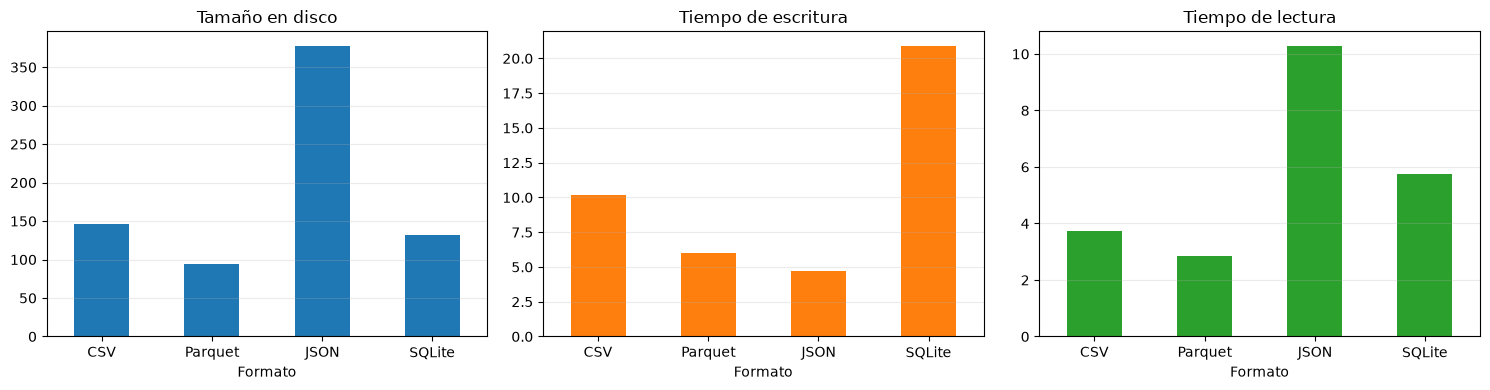

In [12]:
import time
from statistics import median
import matplotlib.pyplot as plt


def write_sqlite():
    with sqlite3.connect(database_path) as connection:
        df.to_sql(table_name, connection, if_exists="replace", index=False)


def read_sqlite():
    with sqlite3.connect(database_path) as connection:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", connection)


writers = {
    "CSV": lambda: df.to_csv(csv_path, index=False),
    "Parquet": lambda: df.to_parquet(parquet_path, index=False),
    "JSON": lambda: df.to_json(json_path, orient="records", indent=2),
    "SQLite": write_sqlite,
}
readers = {
    "CSV": lambda: pd.read_csv(csv_path),
    "Parquet": lambda: pd.read_parquet(parquet_path),
    "JSON": lambda: pd.read_json(json_path, orient="records"),
    "SQLite": read_sqlite,
}

repetitions = 7
benchmark_rows = []

for format_name, writer in writers.items():
    write_times = []
    read_times = []

    for _ in range(repetitions):
        start_time = time.perf_counter()
        writer()
        write_times.append(time.perf_counter() - start_time)

        start_time = time.perf_counter()
        loaded_df = readers[format_name]()
        read_times.append(time.perf_counter() - start_time)
        assert loaded_df.shape == df.shape

    file_paths = {
        "CSV": csv_path,
        "Parquet": parquet_path,
        "JSON": json_path,
        "SQLite": database_path,
    }
    size_bytes = file_paths[format_name].stat().st_size
    benchmark_rows.append(
        {
            "Formato": format_name,
            "Tamaño (KiB)": size_bytes / 1024,
            "Escritura mediana (ms)": median(write_times) * 1000,
            "Lectura mediana (ms)": median(read_times) * 1000,
        }
    )

benchmark = pd.DataFrame(benchmark_rows).set_index("Formato")
benchmark["Tamaño relativo a CSV (%)"] = (
    benchmark["Tamaño (KiB)"] / benchmark.loc["CSV", "Tamaño (KiB)"] * 100
)

print(f"Mediciones para {len(df):,} filas × {len(df.columns)} columnas ({repetitions} repeticiones; se muestra mediana):")
display(benchmark.round(3))

axes = benchmark[
    ["Tamaño (KiB)", "Escritura mediana (ms)", "Lectura mediana (ms)"]
].plot(
    kind="bar",
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    legend=False,
    rot=0,
    title=["Tamaño en disco", "Tiempo de escritura", "Tiempo de lectura"],
)
for axis in axes.flat:
    axis.set_xlabel("Formato")
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Interpretar los resultados

La mejor opción depende de lo que el pipeline necesite: ahorrar almacenamiento, acelerar lecturas, intercambiar datos con otras aplicaciones o consultar tablas con SQL. No existe un formato ganador para todos los casos.

La siguiente lectura resume automáticamente los resultados medidos en la celda anterior. Los tiempos pequeños pueden variar entre ejecuciones y deben interpretarse como una demostración para este dataset y este equipo, no como una garantía de rendimiento general.

In [13]:
smallest_format = benchmark["Tamaño (KiB)"].idxmin()
fastest_write_format = benchmark["Escritura mediana (ms)"].idxmin()
fastest_read_format = benchmark["Lectura mediana (ms)"].idxmin()

csv_size = benchmark.loc["CSV", "Tamaño (KiB)"]
parquet_size = benchmark.loc["Parquet", "Tamaño (KiB)"]
json_size = benchmark.loc["JSON", "Tamaño (KiB)"]

print(f"Formato más pequeño en esta prueba: {smallest_format}.")
print(
    f"Parquet ocupa {(1 - parquet_size / csv_size) * 100:.1f}% menos que CSV "
    "en esta muestra."
)
print(f"Formato con menor mediana de escritura: {fastest_write_format}.")
print(f"Formato con menor mediana de lectura: {fastest_read_format}.")
print(f"JSON ocupa {json_size / csv_size:.2f} veces el tamaño de CSV en esta muestra.")

print("\nLectura didáctica:")
print(
    "- Si importa reducir espacio y leer datos tabulares con eficiencia, "
    "Parquet es el mejor resultado de esta prueba."
)
print(
    "- Si importa que personas o sistemas lean fácilmente los datos como texto, "
    "CSV o JSON pueden ser más cómodos, a cambio de ocupar más espacio."
)
print(
    "- Si se necesitan tablas y consultas SQL, SQLite ofrece esa interfaz; "
    "el costo medido aquí incluye abrir la base y crear/reemplazar la tabla."
)
print(
    "- Los tiempos dependen del tamaño del dataset, el equipo, las bibliotecas, "
    "la caché y las opciones de serialización. Para un pipeline real hay que "
    "repetir la prueba con volúmenes y consultas representativos."
)

Formato más pequeño en esta prueba: Parquet.
Parquet ocupa 35.8% menos que CSV en esta muestra.
Formato con menor mediana de escritura: JSON.
Formato con menor mediana de lectura: Parquet.
JSON ocupa 2.58 veces el tamaño de CSV en esta muestra.

Lectura didáctica:
- Si importa reducir espacio y leer datos tabulares con eficiencia, Parquet es el mejor resultado de esta prueba.
- Si importa que personas o sistemas lean fácilmente los datos como texto, CSV o JSON pueden ser más cómodos, a cambio de ocupar más espacio.
- Si se necesitan tablas y consultas SQL, SQLite ofrece esa interfaz; el costo medido aquí incluye abrir la base y crear/reemplazar la tabla.
- Los tiempos dependen del tamaño del dataset, el equipo, las bibliotecas, la caché y las opciones de serialización. Para un pipeline real hay que repetir la prueba con volúmenes y consultas representativos.
